# Fase 1: Análise Exploratória (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('./manutencao_preditiva.csv', sep=',')


In [3]:
df.head(20)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558.0,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527.0,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667.0,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741.0,28.0,21,0,0,0,0,0,0


## Imagem 01: Visualização das primeiras linhas do DataFrame bruto

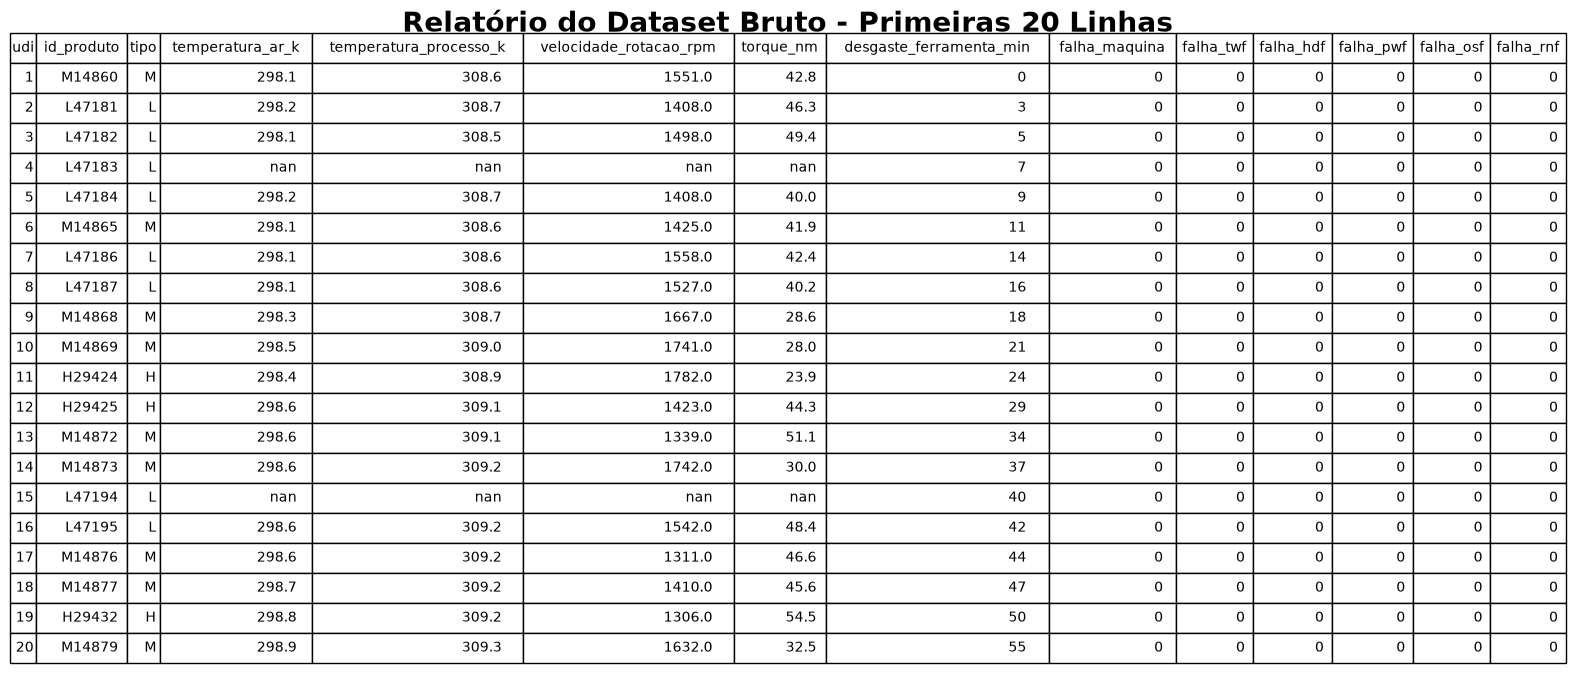

In [4]:
# Pegar as primeiras linhas do dataset
tabela = df.head(20)

# Criar figura
fig, ax = plt.subplots(figsize=(18, 8))

plt.title(
    "Relatório do Dataset Bruto - Primeiras 20 Linhas",
    fontsize=20,
    fontweight="bold"
)

# Remover eixos
ax.axis("off")

# Criar tabela
table = ax.table(
    cellText=tabela.values,
    colLabels=tabela.columns,
    loc="center"
)

# Ajustar tamanho
table.auto_set_font_size(False)
table.set_fontsize(10)


# Ajusta a largura das colunas dinamicamente com base no conteúdo das células
table.auto_set_column_width(col=list(range(len(tabela.columns))))

# Dá um espaçamento maior entre as linhas e colunas da tabela
table.scale(1.2, 1.8)

# Salvar imagem
plt.savefig(
    "imagens/01_dataset_bruto_head.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
print('***Informações do DataFrame***')
print(f'Número de linhas: {df.shape[0]}')
print(f'Número de colunas: {df.shape[1]}')

***Informações do DataFrame***
Número de linhas: 10000
Número de colunas: 14


In [6]:
print('\n***Informações sobre os tipos de dados das variáveis***')
df.dtypes


***Informações sobre os tipos de dados das variáveis***


udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

In [7]:
print('***Resumo estatístico das colunas numéricas***')
df.describe()

***Resumo estatístico das colunas numéricas***


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
print(df.columns.tolist())

['udi', 'id_produto', 'tipo', 'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']


In [9]:
print(df.isnull().sum())

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64


## Gráfico 02: Histograma das Variáveis Preditoras

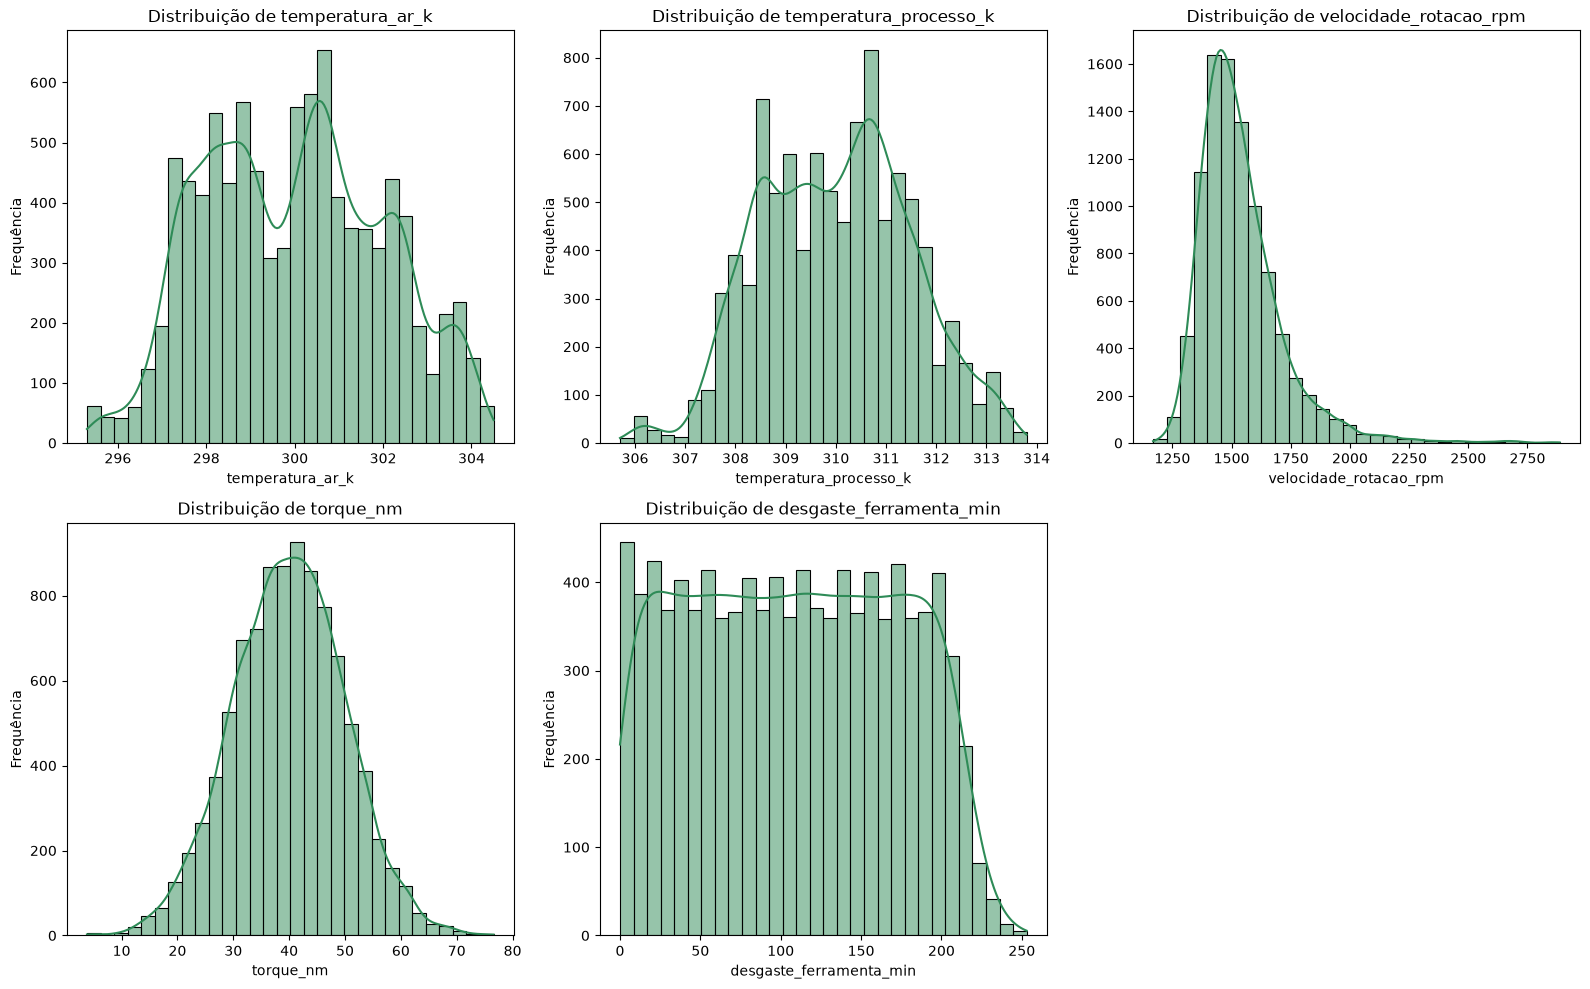

In [10]:
colunas_sensores = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

plt.figure(figsize=(16, 10))

for i, coluna in enumerate(colunas_sensores, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=coluna, kde=True, color='seagreen', bins=30)
    plt.title(f'Distribuição de {coluna}', fontsize=12)
    plt.xlabel(coluna, fontsize=10)
    plt.ylabel('Frequência', fontsize=10)

plt.tight_layout()
plt.savefig('imagens/02_distribuicao_sensores.png', dpi=300, bbox_inches='tight')
plt.show()

O histograma apresenta a distribuição das principais variáveis monitoradas pelos sensores da máquina. Observa-se a frequência com que determinados valores de temperatura, velocidade de rotação, torque e desgaste da ferramenta ocorrem na base de dados. Essa análise permite identificar a concentração dos valores, possíveis assimetrias, dispersões e indícios de valores extremos, fornecendo uma visão inicial da qualidade dos dados e do comportamento das variáveis que serão utilizadas para prever falhas mecânicas. Essas informações auxiliam na escolha das técnicas de pré-processamento e na construção de modelos de classificação mais adequados.

## Gráfico 03: Countplot da variável alvo

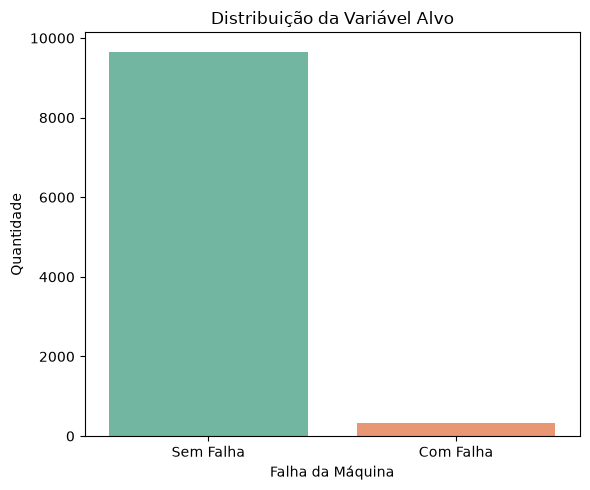

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='falha_maquina',
    hue='falha_maquina',
    palette='Set2',
    legend=False
)

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Falha da Máquina')
plt.ylabel('Quantidade')

plt.xticks(
    [0,1],
    ['Sem Falha','Com Falha']
)

plt.tight_layout()
plt.savefig("imagens/03_balanceamento.png", dpi=300)
plt.show()


In [12]:
(df['falha_maquina']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))

falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64

96,61% dos registros representam máquinas em funcionamento normal (falha_maquina = 0).
3,39% dos registros representam máquinas que apresentaram falha (falha_maquina = 1).

## Gráfico 04: Heatmap da correlação

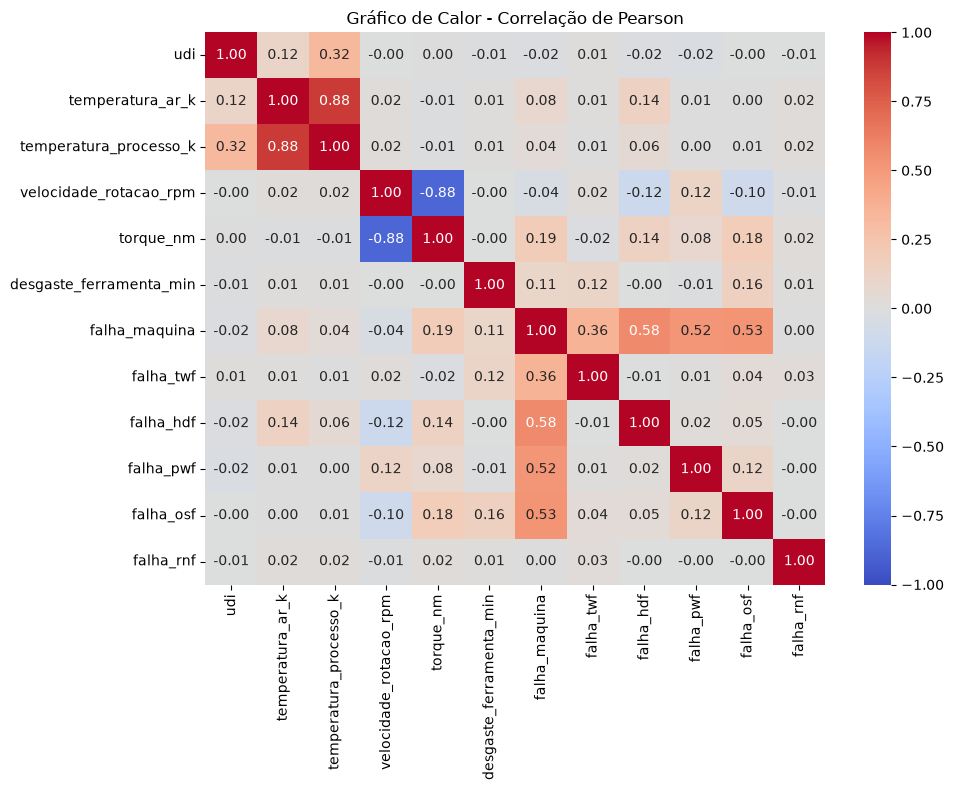

In [13]:
# Calcula a matriz de correlação de Pearson
matriz_correlacao = df.corr(method='pearson', numeric_only=True)
# Desenha o gráfico de calor 
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, 
vmax=1) 
plt.title('Gráfico de Calor - Correlação de Pearson') 
plt.tight_layout()
plt.savefig("imagens/04_heatmap.png", dpi=300)
plt.show()

### Análise Estratégica do Mapa de Calor (Correlação de Pearson)

O mapa de calor mostra relações importantes entre variáveis que impactam diretamente a modelagem:

1. `velocidade_rotacao_rpm` e `torque_nm` apresentam correlação negativa muito forte, justificando a criação da variável `potencia` para capturar essa interação física.
2. Variáveis de motivo de falha como `falha_hdf`, `falha_osf` e `falha_pwf` têm alta correlação com `falha_maquina`, o que indica risco de vazamento de dados (data leakage). Por isso elas são removidas antes do treinamento.
3. As variáveis operam em escalas diferentes. Para evitar que o modelo priorize uma variável apenas pelo tamanho do seu valor, o StandardScaler foi adotado no KNN.

🔴 Vermelho → correlação positiva.
🔵 Azul → correlação negativa.
⚪ Próximo do branco → correlação próxima de zero.

## Fase 2: Limpeza e Tratamento de Dados (Data Prep) e criação de cópia independente

In [14]:
df_limpo = df.copy()

In [15]:
df_limpo

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


## Verificação e limpeza dos dados ausentes e duplicados

In [16]:
# Conta quantos dados ausentes existem em cada coluna
df_limpo.isnull().sum()

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [17]:
# Mostra apenas as linhas que possuem qualquer valor ausente
df_limpo[df_limpo.isnull().any(axis=1)]

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
14,15,L47194,L,NaN,NaN,NaN,NaN,40,0,0,0,0,0,0
29,30,L47209,L,NaN,NaN,NaN,NaN,84,0,0,0,0,0,0
31,32,L47211,L,NaN,NaN,NaN,NaN,89,0,0,0,0,0,0
33,34,L47213,L,NaN,NaN,NaN,NaN,93,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9783,9784,H39197,H,NaN,NaN,NaN,NaN,66,0,0,0,0,0,0
9896,9897,M24756,M,NaN,NaN,NaN,NaN,173,0,0,0,0,0,0
9909,9910,L57089,L,NaN,NaN,NaN,NaN,2,0,0,0,0,0,0
9920,9921,H39334,H,NaN,NaN,NaN,NaN,28,0,0,0,0,0,0


In [18]:
# Conta o total de linhas 100% duplicadas no DataFrame
total_duplicadas = df_limpo.duplicated().sum()
print(f'Total de linhas duplicadas: {total_duplicadas}')

Total de linhas duplicadas: 0


In [19]:
# Exibe as linhas duplicadas no DataFrame
linhas_duplicadas = df_limpo[df_limpo.duplicated(keep=False)]
print(f'Linhas duplicadas:\n{linhas_duplicadas}')

Linhas duplicadas:
Empty DataFrame
Columns: [udi, id_produto, tipo, temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm, torque_nm, desgaste_ferramenta_min, falha_maquina, falha_twf, falha_hdf, falha_pwf, falha_osf, falha_rnf]
Index: []


## Uso da média e da mediana para preenchimento dos dados ausentes

## Gráfico 05: Com outliers

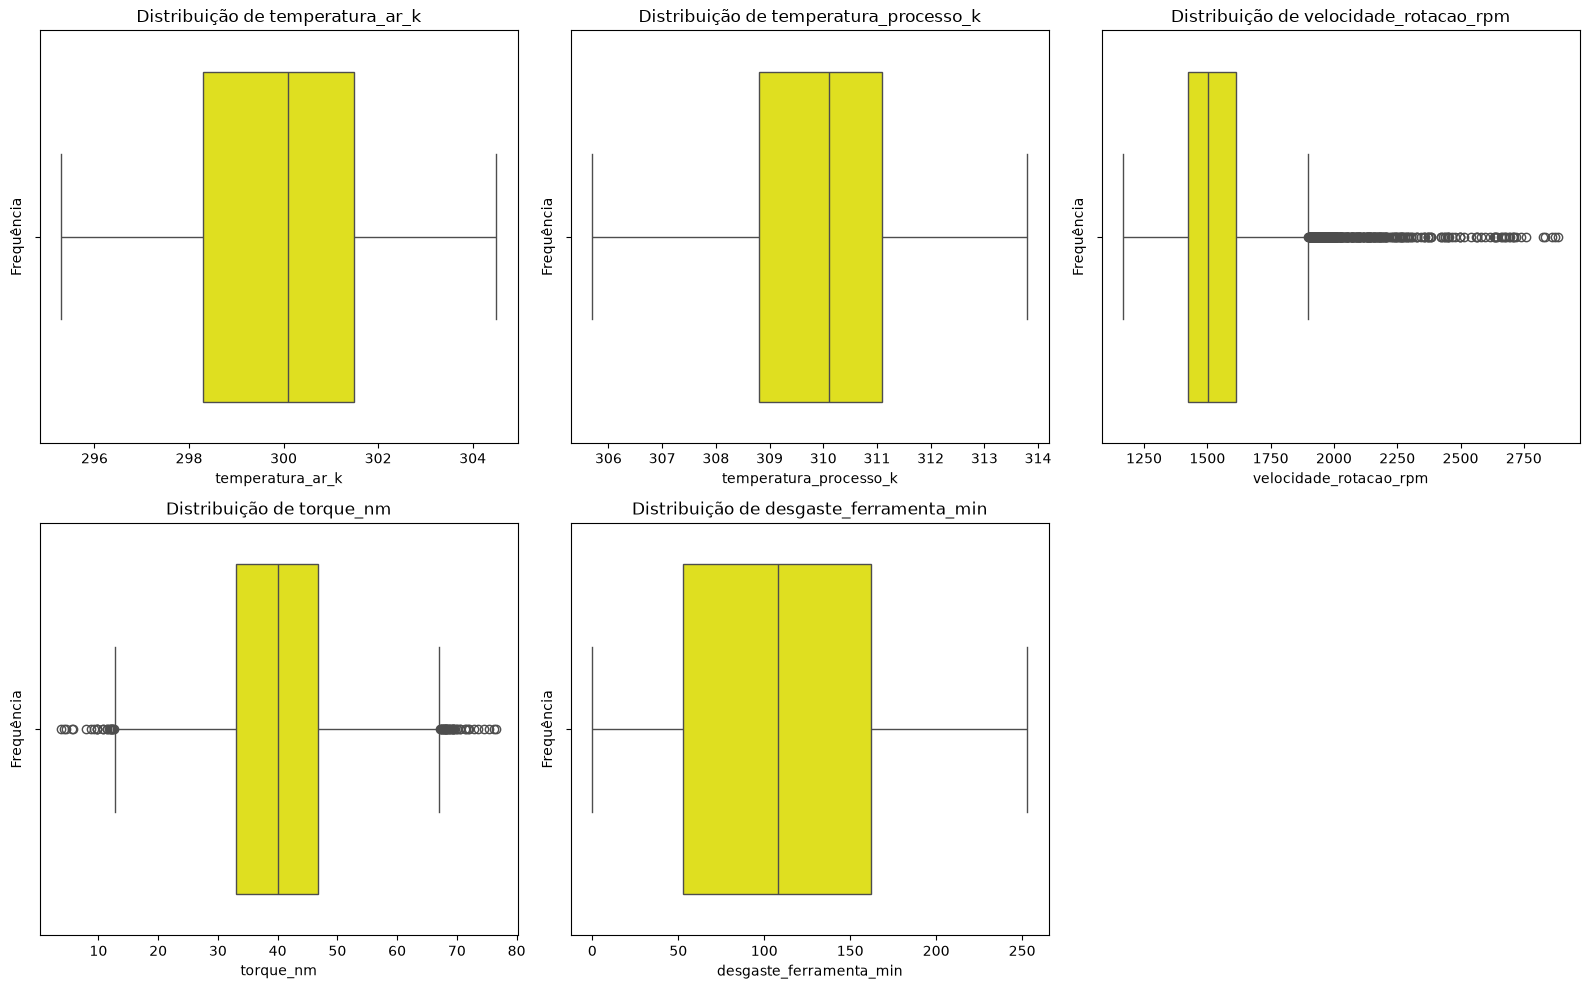

In [20]:
outlier_colunas_sensores = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

plt.figure(figsize=(16, 10))

for i, coluna in enumerate(colunas_sensores, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=coluna, color='yellow', showfliers=True)
    plt.title(f'Distribuição de {coluna}', fontsize=12)
    plt.xlabel(coluna, fontsize=10)
    plt.ylabel('Frequência', fontsize=10)

plt.tight_layout()
plt.savefig('imagens/05_boxplot_sensores_com_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

## A escolha da mediana se deu pela presença clara de outliers nas extremidades dessas distribuições, pois sofre menos influência dos valores extremos e preserva a tendência central dos dados.

In [21]:
mediana_rotacao = df_limpo['velocidade_rotacao_rpm'].median()
df_limpo['velocidade_rotacao_rpm'] = df_limpo['velocidade_rotacao_rpm'].fillna(mediana_rotacao)

In [22]:
mediana_torque = df_limpo['torque_nm'].median()
df_limpo['torque_nm'] = df_limpo['torque_nm'].fillna(mediana_torque)

## A escolha da média se deu pelas distribuições simétricas e bem comportadas, sem a ocorrência de outliers significativos. Neste cenário, a média representa bem o centro dos dados.

In [23]:
media_temp = df_limpo['temperatura_ar_k'].mean()
df_limpo['temperatura_ar_k'] = df_limpo['temperatura_ar_k'].fillna(media_temp)

In [24]:
media_processo = df_limpo['temperatura_processo_k'].mean()
df_limpo['temperatura_processo_k'] = df_limpo['temperatura_processo_k'].fillna(media_processo)

In [25]:
# Mostra o df_limpo atualizado após o tratamento de valores ausentes
df_limpo.isnull().sum()

udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64

In [26]:
# Mostra o df_limpo atualizado após o tratamento de valores ausentes
df_limpo[df_limpo.isnull().any(axis=1)]

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf


In [27]:
df_limpo.head(20)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.100000,308.600000,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.200000,308.700000,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.100000,308.500000,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,300.002158,310.000895,1504.0,40.1,7,0,0,0,0,0,0
4,5,L47184,L,298.200000,308.700000,1408.0,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.100000,308.600000,1425.0,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.100000,308.600000,1558.0,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.100000,308.600000,1527.0,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.300000,308.700000,1667.0,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.500000,309.000000,1741.0,28.0,21,0,0,0,0,0,0


## Imagem 06: Visualização das primeiras linhas do DataFrame limpo

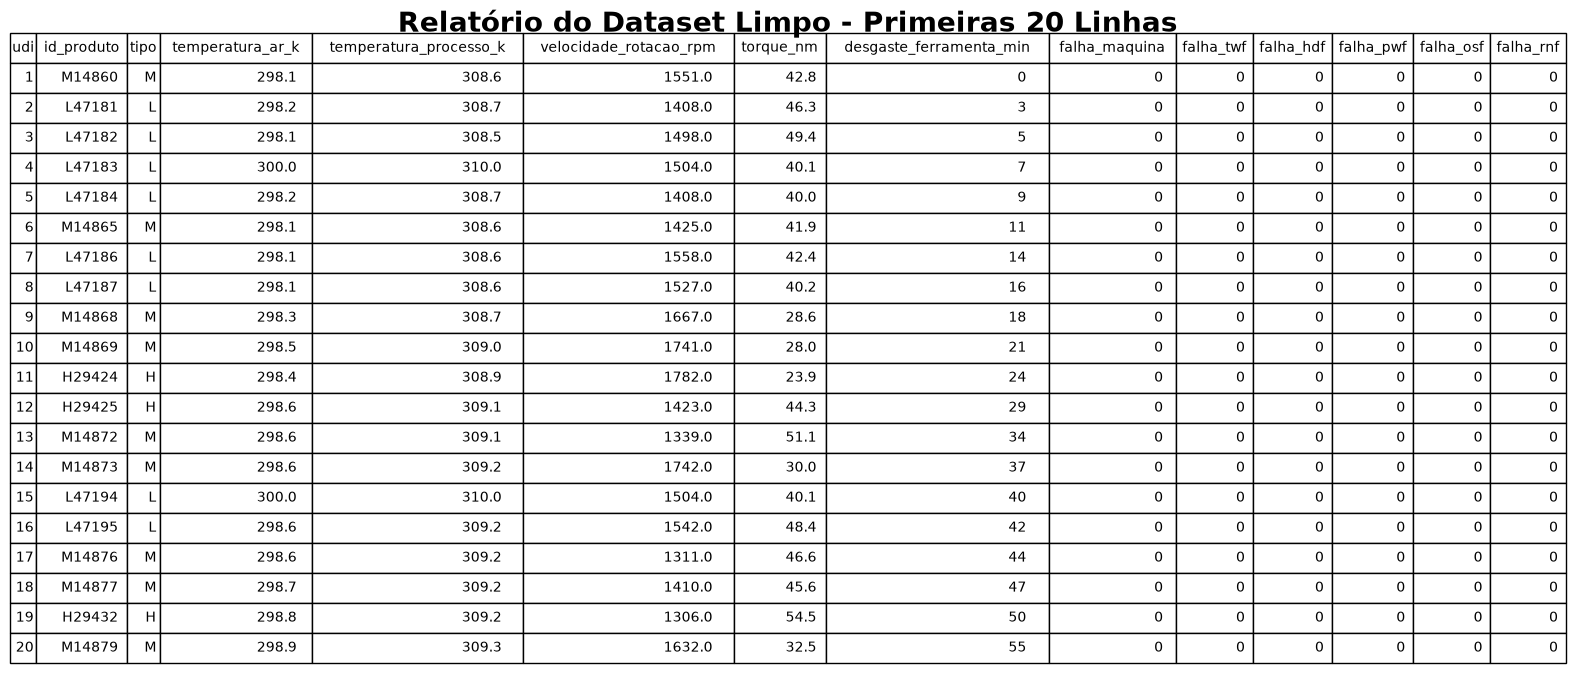

In [28]:
# Pegar as primeiras linhas do dataset
tabela = df_limpo.head(20)

# Criar figura
fig, ax = plt.subplots(figsize=(18, 8))

plt.title(
    "Relatório do Dataset Limpo - Primeiras 20 Linhas",
    fontsize=20,
    fontweight="bold"
)

# Remover eixos
ax.axis("off")

# Formatar os valores da tabela para exibir apenas uma casa decimal
tabela_formatada = tabela.round(1)

# Criar tabela
table = ax.table(
    cellText=tabela_formatada.values,
    colLabels=tabela_formatada.columns,
    loc="center"
)

# Ajustar tamanho
table.auto_set_font_size(False)
table.set_fontsize(10)

# Ajusta a largura das colunas dinamicamente com base no conteúdo das células
table.auto_set_column_width(col=list(range(len(tabela.columns))))

# Dá um espaçamento maior entre as linhas e colunas da tabela
table.scale(1.2, 1.8)

# Salvar imagem
plt.savefig(
    "imagens/06_dataset_limpo_head.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Gráfico 07: Sem outliers

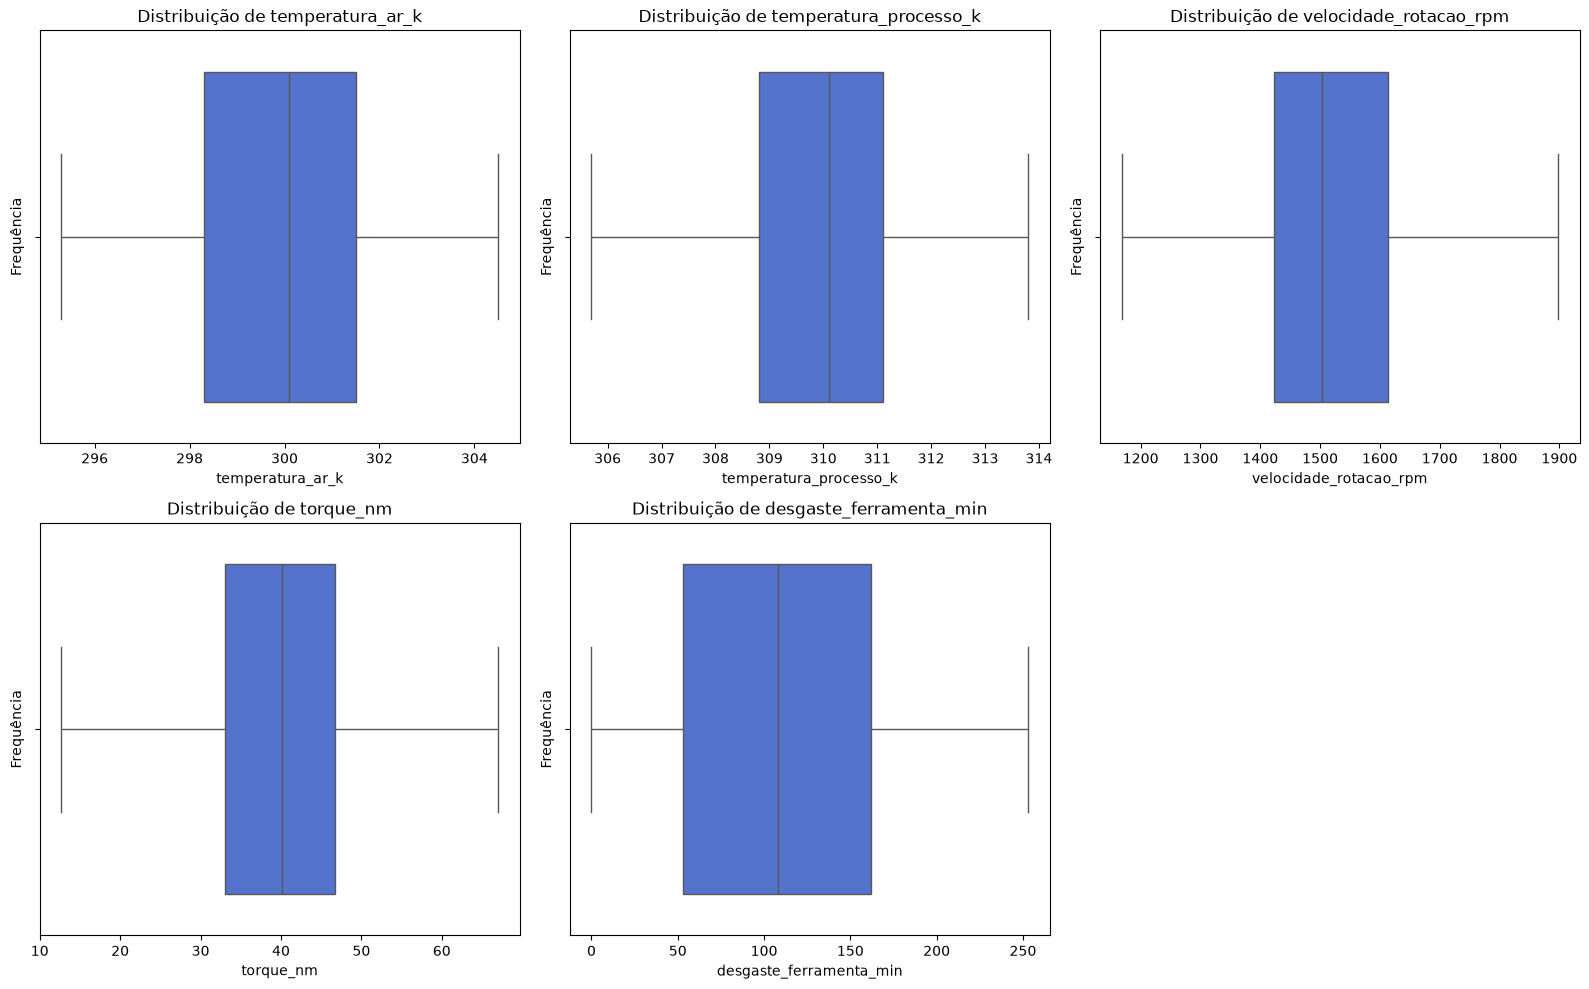

In [29]:
outlier_colunas_sensores = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

plt.figure(figsize=(16, 10))

for i, coluna in enumerate(colunas_sensores, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=coluna, color='royalblue', showfliers=False)
    plt.title(f'Distribuição de {coluna}', fontsize=12)
    plt.xlabel(coluna, fontsize=10)
    plt.ylabel('Frequência', fontsize=10)

plt.tight_layout()
plt.savefig('imagens/07_boxplot_sensores_sem_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

## Fase 3: Feature Engineering

In [30]:
df_limpo['potencia'] = df_limpo['velocidade_rotacao_rpm'] * df_limpo['torque_nm']

df_limpo[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head(5)

,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


## Fase 4: Divisão e balanceamento dos dados

### Balanceamento das Classes com SMOTE

A base é altamente desbalanceada: há muito mais exemplos de máquina funcionando do que de máquina com falha. Para evitar que o modelo aprenda apenas a classe majoritária, aplicamos SMOTE apenas no conjunto de treino. O conjunto de teste permanece com a distribuição original, garantindo uma avaliação mais realista.

In [31]:
# Colunas que não serão utilizadas como variáveis preditoras
features_to_drop = [
    'udi',
    'id_produto',
    'falha_maquina',
    'falha_twf',
    'falha_hdf',
    'falha_pwf',
    'falha_osf',
    'falha_rnf'
]

# Variáveis independentes (X) e variável alvo (y)
X = df_limpo.drop(columns=features_to_drop)
y = df_limpo['falha_maquina']

# Converter variáveis categóricas em numéricas
X = pd.get_dummies(X, drop_first=True)

# Dividir em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Aplicar o SMOTE apenas no conjunto de treinamento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Exibir informações dos conjuntos
print("Treino após SMOTE:", X_train_smote.shape, y_train_smote.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino após SMOTE: (15458, 8) (15458,)
Teste: (2000, 8) (2000,)


In [32]:
print("Antes do SMOTE")
print(y.value_counts())

print("\nDepois do SMOTE")
print(y_train_smote.value_counts())

Antes do SMOTE
falha_maquina
0    9661
1     339
Name: count, dtype: int64

Depois do SMOTE
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


## Imagem 08: Visualização antes e depois do SMOTE

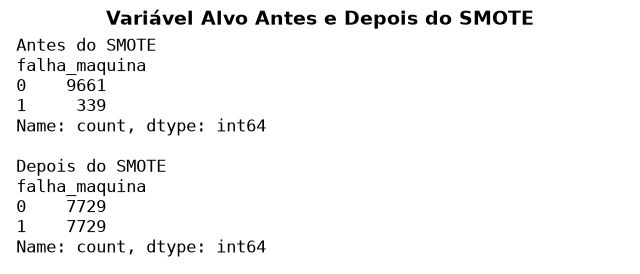

In [33]:
texto = (
    "Antes do SMOTE\n"
    f"{y.value_counts()}\n\n"
    "Depois do SMOTE\n"
    f"{y_train_smote.value_counts()}"
)

fig = plt.figure(figsize=(8, 3))

plt.title(
    "Variável Alvo Antes e Depois do SMOTE",
    fontsize=14,
    fontweight="bold"
)



plt.text(
    0.01,
    0.05,
    texto,
    fontsize=12,
    family="monospace"
)

plt.axis("off")

plt.savefig(
    "imagens/08_smote_balanceamento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Fase 5: Escalonamento de variáveis (StandardScaler)

Nesta etapa, ajustamos a escala de todas as variáveis numéricas do conjunto de dados:

1. Padronização: Como temos variáveis em escalas totalmente diferentes (ex: velocidade na casa dos milhares e torque na casa das dezenas), usamos o StandardScaler para que todas fiquem na mesma ordem de grandeza (média 0 e desvio padrão 1).
2. Prevenção de Data Leakage: O ajuste (fit_transform) foi aplicado apenas nos dados de treino. Os dados de teste foram apenas transformados (transform), garantindo que o modelo não conheça a média ou o desvio padrão dos dados de teste antes da avaliação.


In [34]:
numerical_cols = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min',
    'potencia'
]
categorical_cols = [col for col in X_train_smote.columns if col not in numerical_cols]

# Separar as features numéricas e categóricas (já one-hot encoded)
X_train_smote_numeric = X_train_smote[numerical_cols]
X_test_numeric = X_test[numerical_cols]
X_train_smote_categorical = X_train_smote[categorical_cols]
X_test_categorical = X_test[categorical_cols]

# Escalonamento para Modelo KNN (apenas nas features numéricas)
scaler = StandardScaler()

# Ajustar e transformar APENAS os dados numéricos de treino balanceados
X_train_scaled_numeric = scaler.fit_transform(X_train_smote_numeric)

# Transformar os dados numéricos de teste usando o mesmo aprendizado do treino
X_test_scaled_numeric = scaler.transform(X_test_numeric)

# Reconstruir os DataFrames para KNN, combinando as features numéricas escalonadas com as categóricas originais
X_train_knn = pd.DataFrame(
    X_train_scaled_numeric,
    columns=numerical_cols,
    index=X_train_smote_numeric.index
)
X_train_knn = pd.concat([X_train_knn, X_train_smote_categorical], axis=1)

X_test_knn = pd.DataFrame(
    X_test_scaled_numeric,
    columns=numerical_cols,
    index=X_test_numeric.index
)
X_test_knn = pd.concat([X_test_knn, X_test_categorical], axis=1)

# Para Decision Tree e Random Forest, usaremos X_train_smote e X_test (com features numéricas não escalonadas)
# Isso já está implicitamente coberto pois X_train_smote e X_test já são os DataFrames com as features originais (numéricas e categóricas one-hot encoded)

print("Conjunto de treinamento KNN escalonado (primeiras 5 linhas):")
print(X_train_knn.head())

print("\nConjunto de teste KNN escalonado (primeiras 5 linhas):")
print(X_test_knn.head())

Conjunto de treinamento KNN escalonado (primeiras 5 linhas):
   temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
0         -0.223599               -0.119453               -0.055385   
1         -1.820140               -1.428760               -0.413819   
2          0.307051                1.111498               -0.557193   
3         -0.809724               -0.274097               -0.372855   
4         -1.766960               -1.274805                0.726344   

   torque_nm  desgaste_ferramenta_min  potencia  tipo_L  tipo_M  
0  -0.323475                -1.048131 -0.277696   False    True  
1   0.121609                 0.127521  0.033353   False    True  
2   0.065091                 0.202884 -0.171688   False    True  
3   0.821028                -0.595957  1.014889    True   False  
4  -1.128866                -1.108421 -0.992158    True   False  

Conjunto de teste KNN escalonado (primeiras 5 linhas):
      temperatura_ar_k  temperatura_processo_k  velocidade_r

## Fase 6: Ajuste de parâmetros e combate ao overfitting

## Modelo KNN

## Análise do KNN (Overfitting e escalabilidade)

Identificação de Overfitting: Ocorre um leve sinal em k=3. Nessa configuração, o modelo alcançou a maior acurácia de treino (97,10%), mas a distância para acurácia de teste (91,35%) é a maior entre os testes (uma difrença de 5,75%). Isso mostra que o k=3 ficou um pouco mais ajustado aos dados do treino.

Configuração mais estável: A configuração mais estável para a acurácia geral é k=5 e k=7, onde a diferença de treino e teste diminue (mais ou menos 5,2%). No entanto, olhando o equilibrio das métricas, k=5 entrega o melhor f1-Score (32,09%) e um bom Recall (63,24%), sem perder muita acurácia.

In [35]:
knn_results = []
for k in (3,5,7):
    # Criação do modelo KNN
    knn = KNeighborsClassifier(n_neighbors=k)

    # Treinamento do modelo
    knn.fit(X_train_knn, y_train_smote)

    # Previsão no conjunto de teste
    y_pred = knn.predict(X_test_knn)
    y_pred_train = knn.predict(X_train_knn)

    # Avaliação do modelo
    accuracy_treino = accuracy_score(y_train_smote, y_pred_train)
    accuracy_teste = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Armazenar os resultados
    knn_results.append({
        'k': k,
        'accuracy_treino': accuracy_treino,
        'accuracy_teste': accuracy_teste,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })
    print(f"Resultados para k={k}:")
    print(f"Accuracy treino: {accuracy_treino:.4f}")
    print(f"Accuracy teste: {accuracy_teste:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

Resultados para k=3:
Accuracy treino: 0.9711
Accuracy teste: 0.9135
Precision: 0.2162
Recall: 0.5882
F1-Score: 0.3162

Resultados para k=5:
Accuracy treino: 0.9611
Accuracy teste: 0.9090
Precision: 0.2150
Recall: 0.6324
F1-Score: 0.3209

Resultados para k=7:
Accuracy treino: 0.9543
Accuracy teste: 0.9015
Precision: 0.2055
Recall: 0.6618
F1-Score: 0.3136



In [36]:
# Criar DataFrame com os resultados
df_knn_results = pd.DataFrame(knn_results)

# Arredondar para 3 casas decimais
df_knn_results = df_knn_results.round(3)

# Exibir resultados
display(df_knn_results)

,k,accuracy_treino,accuracy_teste,precision,recall,f1_score
0,3,0.971,0.914,0.216,0.588,0.316
1,5,0.961,0.909,0.215,0.632,0.321
2,7,0.954,0.902,0.205,0.662,0.314


## Imagem 09: Visualização do modelo KNN

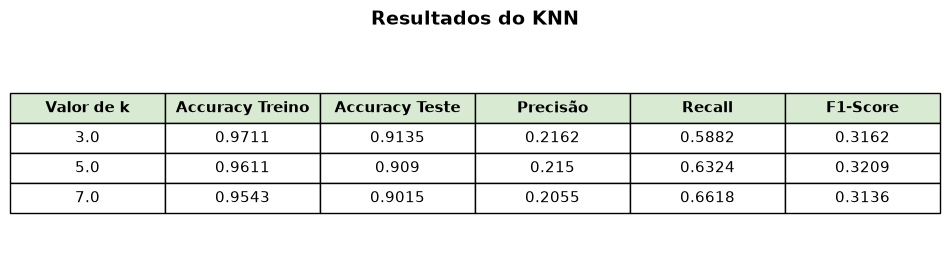

In [37]:
# Criar DataFrame
df_knn_results = pd.DataFrame(knn_results)

# Renomear colunas para exibição
df_knn_img = df_knn_results.rename(columns={
    "k": "Valor de k",
    "accuracy_treino": "Accuracy Treino",
    "accuracy_teste": "Accuracy Teste",
    "precision": "Precisão",
    "recall": "Recall",
    "f1_score": "F1-Score"
})

# Arredondar métricas
colunas_metricas = [
    "Accuracy Treino",
    "Accuracy Teste",
    "Precisão",
    "Recall",
    "F1-Score"
]

df_knn_img[colunas_metricas] = df_knn_img[colunas_metricas].round(4)

# Criar figura
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

# Criar tabela
table = ax.table(
    cellText=df_knn_img.values,
    colLabels=df_knn_img.columns,
    cellLoc="center",
    loc="center"
)

# Ajustar tamanho
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Destacar cabeçalho
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAD3")

# Título
plt.title(
    "Resultados do KNN",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# Salvar imagem
plt.savefig(
    "imagens/09_resultados_knn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Modelo Árvore de Decisão

Ocorrência de Overfitting: O Overfitting ocorreu de forma explícita na configuração max_depth=None (profundidade ilimitda). O modelo memorizou os dados de treinamento, atingindo uma acurácia de treino extremamente elevada (99,45%), com isso o modelo deixa falhas generalizadas em modelos reais fora do conjunto controlado.

Configuração de Estabilidade: A configuração que garantiu a melhor estabilidade e o melhor equilbrio para o modelo foi max_depth=5. Nessa profundidade, a acurácia de treino e teste mantiveram muito próximas e equilibradas, provando alta capacidade de generalização. Além disso, essa configuração apresentou uma evolução sólida no F1-Score (36,69%) e no Recall (75,00%) se comparando á profundidade de corte igual a 3.



In [38]:
# Lista para armazenar os resultados
tree_results = []

# Criar e treinar o modelo Decision Tree
profundidades = [3, 5, None]  # Adicione None para permitir profundidade ilimitada

for depth in profundidades:
    # Criação do modelo Decision Tree
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Treinamento do modelo
    dt.fit(X_train_smote, y_train_smote)

    # Previsão no conjunto de teste
    y_pred = dt.predict(X_test)
    y_pred_train = dt.predict(X_train_smote)

    # Avaliação do modelo
    accuracy_treino = accuracy_score(y_train_smote, y_pred_train)
    accuracy_teste = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

        # Armazenar os resultados
    tree_results.append({
        "Profundidade": "Ilimitada" if depth is None else depth,
        'accuracy_treino': accuracy_treino,
        'accuracy_teste': accuracy_teste,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

    # Armazenar os resultados
    print(f"\nDecision Tree (max_depth = {'Ilimitada' if depth is None else depth})")
    print(f"Accuracy treino: {accuracy_treino:.4f}")
    print(f"Accuracy teste: {accuracy_teste:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")# Calcular as métricas finais


Decision Tree (max_depth = 3)
Accuracy treino: 0.8579
Accuracy teste: 0.8595
Precision: 0.1365
Recall: 0.5882
F1-Score: 0.2216


Decision Tree (max_depth = 5)
Accuracy treino: 0.9034
Accuracy teste: 0.9120
Precision: 0.2429
Recall: 0.7500
F1-Score: 0.3669


Decision Tree (max_depth = Ilimitada)
Accuracy treino: 0.9945
Accuracy teste: 0.9435
Precision: 0.3427
Recall: 0.7206
F1-Score: 0.4645



In [39]:
# Criar DataFrame com os resultados
df_tree_results = pd.DataFrame(tree_results)

# Arredondar para 3 casas decimais
df_tree_results = df_tree_results.round(3)

# Exibir resultados
display(df_tree_results)

,Profundidade,accuracy_treino,accuracy_teste,precision,recall,f1_score
0,3,0.858,0.860,0.137,0.588,0.222
1,5,0.903,0.912,0.243,0.750,0.367
2,Ilimitada,0.995,0.944,0.343,0.721,0.464


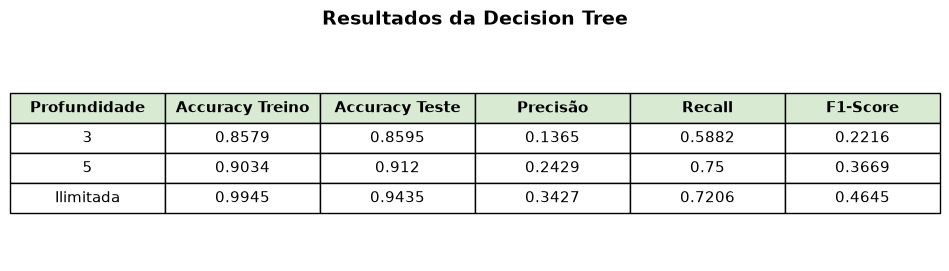

In [40]:
# Criar DataFrame
df_tree_results = pd.DataFrame(tree_results)

# Renomear colunas para exibição
df_tree_img = df_tree_results.rename(columns={
    "accuracy_treino": "Accuracy Treino",
    "accuracy_teste": "Accuracy Teste",
    "precision": "Precisão",
    "recall": "Recall",
    "f1_score": "F1-Score"
})

# Arredondar métricas
colunas_metricas = [
    "Accuracy Treino",
    "Accuracy Teste",
    "Precisão",
    "Recall",
    "F1-Score"
]

df_tree_img[colunas_metricas] = df_tree_img[colunas_metricas].round(4)

# Criar figura
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

# Criar tabela
table = ax.table(
    cellText=df_tree_img.values,
    colLabels=df_tree_img.columns,
    cellLoc="center",
    loc="center"
)

# Ajustar tamanho
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Destacar cabeçalho
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAD3")

# Título
plt.title(
    "Resultados da Decision Tree",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# Salvar imagem
plt.savefig(
    "imagens/10_resultados_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Modelo Random Forest

## Random Forest


A tabela apresenta o impacto do hiperparametro max_depth nas métricas do modelo:

1. Ajuste de Complexidade: O modelo com Profundidade 3 apresenta sinais de underfitting comparado aos demais, com menor acurácia geral. Já a Profundidade Ilimitada demonstra overfitting, visto que a acurácia de treino atinge 99.4%, mas não se traduz no melhor desempenho de teste.
2. Modelo Ideal: A Profundidade 5 foi a que obteve o melhor equilíbrio (trade-off), alcançando a maior estabilidade entre treino e teste, além do maior F1-Score prático equilibrando a capacidade preditiva.
3. Comportamento das Métricas: Identifica-se uma relação inversa entre Precisão e Recall. Conforme a profundidade cresce, o modelo se torna mais estrito (aumentando a Precisão de 60.4% para 68.6%), porém reduz a sua sensibilidade em detectar todos os alvos (reduzindo o Recall de 84% para 77.7%).


In [41]:

# Profundidades a serem testadas
profundidades = [3, 5, None]
rf_results = [] # Garanta que a lista comece vazia

for depth in profundidades:
    
    # Criar modelo
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    
    # Treinar o modelo
    rf_model.fit(X_train_smote, y_train_smote)
    
    # Fazer previsões
    y_pred_train = rf_model.predict(X_train_smote) # Previsão para o treino
    y_pred_test = rf_model.predict(X_test)         # Previsão para o teste
    
    # --- CALCULAR AS MÉTRICAS AGORA (O que faltava!) ---
    acc_tr = accuracy_score(y_train_smote, y_pred_train)
    acc_te = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, average='macro') # ajuste o 'average' se for multiclasse
    rec = recall_score(y_test, y_pred_test, average='macro')
    f1_val = f1_score(y_test, y_pred_test, average='macro')
    
    # Armazenar os resultados atualizados
    rf_results.append({
        "Profundidade": "Ilimitada" if depth is None else depth,
        'accuracy_treino': acc_tr,
        'accuracy_teste': acc_te,
        'precision': prec,
        'recall': rec,
        'f1_score': f1_val
    })
    
    print(f"\nRandom Forest (max_depth = {'Ilimitada' if depth is None else depth})")
    print(classification_report(y_test, y_pred_test))


Random Forest (max_depth = 3)
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1932
           1       0.22      0.78      0.34        68

    accuracy                           0.90      2000
   macro avg       0.60      0.84      0.64      2000
weighted avg       0.97      0.90      0.92      2000


Random Forest (max_depth = 5)
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1932
           1       0.26      0.75      0.38        68

    accuracy                           0.92      2000
   macro avg       0.62      0.84      0.67      2000
weighted avg       0.97      0.92      0.94      2000


Random Forest (max_depth = Ilimitada)
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.39      0.59      0.47        68

    accuracy                           0.95      2000
   macro avg       0.69    

In [42]:
# Criar DataFrame com os resultados
df_rf_results = pd.DataFrame(rf_results)

# Arredondar para 3 casas decimais
df_rf_results = df_rf_results.round(3)

# Exibir resultados
display(df_rf_results)

,Profundidade,accuracy_treino,accuracy_teste,precision,recall,f1_score
0,3,0.855,0.897,0.604,0.840,0.642
1,5,0.907,0.917,0.623,0.836,0.668
2,Ilimitada,0.995,0.954,0.687,0.778,0.722


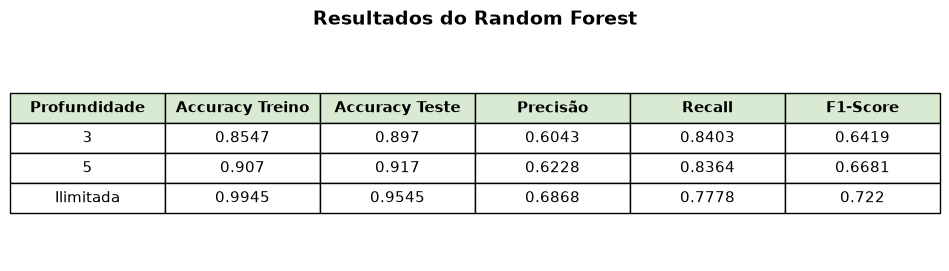

In [43]:
# Criar DataFrame
df_rf_results = pd.DataFrame(rf_results)

# Renomear colunas para exibição
df_rf_img = df_rf_results.rename(columns={
    "accuracy_treino": "Accuracy Treino",
    "accuracy_teste": "Accuracy Teste",
    "precision": "Precisão",
    "recall": "Recall",
    "f1_score": "F1-Score"
})

# Arredondar métricas
colunas_metricas = [
    "Accuracy Treino",
    "Accuracy Teste",
    "Precisão",
    "Recall",
    "F1-Score"
]

df_rf_img[colunas_metricas] = df_rf_img[colunas_metricas].round(4)

# Criar figura
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

# Criar tabela
table = ax.table(
    cellText=df_rf_img.values,
    colLabels=df_rf_img.columns,
    cellLoc="center",
    loc="center"
)

# Ajustar tamanho
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Destacar cabeçalho
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAD3")

# Título
plt.title(
    "Resultados do Random Forest",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# Salvar imagem
plt.savefig(
    "imagens/11_resultados_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Fase 7: Avaliação da acurácia

In [44]:
melhor_knn = KNeighborsClassifier(n_neighbors=5)
melhor_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
melhor_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

# Treinar os modelos com os dados balenceados (SMOTE) e escalonados/não escalonados apropriadamente
melhor_knn.fit(X_train_knn, y_train_smote)
melhor_tree.fit(X_train_smote, y_train_smote)
melhor_rf.fit(X_train_smote, y_train_smote)

# Gerar previsões nos dados de teste escalonados/não escalonados apropriadamente
y_pred_knn_final = melhor_knn.predict(X_test_knn)
y_pred_tree_final = melhor_tree.predict(X_test)
y_pred_rf_final = melhor_rf.predict(X_test)

# Exibir resultados de forma comparativa
print("=== Comparativo Final de Acurácia (Dados de Teste) ===")
print(f"Acurácia Final do KNN (k=5): {accuracy_score(y_test, y_pred_knn_final):.4f}")
print(f"Acurácia Final do Decision Tree (max_depth=5): {accuracy_score(y_test, y_pred_tree_final):.4f}")
print(f"Acurácia Final do Random Forest (max_depth=5): {accuracy_score(y_test, y_pred_rf_final):.4f}")

=== Comparativo Final de Acurácia (Dados de Teste) ===
Acurácia Final do KNN (k=5): 0.9090
Acurácia Final do Decision Tree (max_depth=5): 0.9120
Acurácia Final do Random Forest (max_depth=5): 0.9170


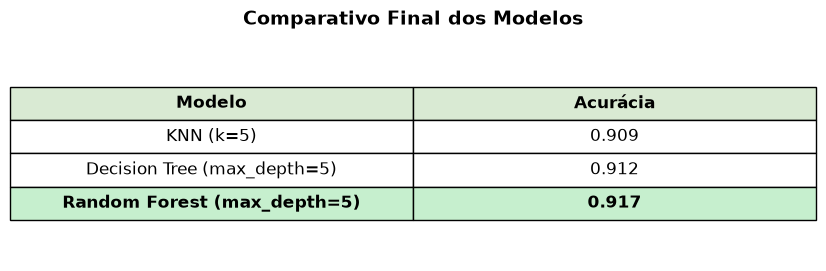

In [45]:
# Criar DataFrame com os resultados finais
df_final = pd.DataFrame({
    "Modelo": [
        "KNN (k=5)",
        "Decision Tree (max_depth=5)",
        "Random Forest (max_depth=5)"
    ],
    "Acurácia": [
        accuracy_score(y_test, y_pred_knn_final),
        accuracy_score(y_test, y_pred_tree_final),
        accuracy_score(y_test, y_pred_rf_final)
    ]
})

# Arredondar valores
df_final["Acurácia"] = df_final["Acurácia"].round(4)

# Criar figura
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis("off")

# Criar tabela
table = ax.table(
    cellText=df_final.values,
    colLabels=df_final.columns,
    cellLoc="center",
    loc="center"
)

# Ajustar aparência
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 2)

# Destacar cabeçalho
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAD3")

# Destacar a melhor acurácia
melhor_linha = df_final["Acurácia"].idxmax() + 1  # +1 porque a linha 0 é o cabeçalho
for col in range(len(df_final.columns)):
    table[(melhor_linha, col)].set_facecolor("#C6EFCE")
    table[(melhor_linha, col)].set_text_props(weight="bold")

# Título
plt.title(
    "Comparativo Final dos Modelos",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# Salvar imagem
plt.savefig(
    "imagens/12_comparativo_final_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Fase 8: Matriz de confusão e veredito final

### Conclusão

A Random Forest com `max_depth=5` foi escolhida por apresentar o melhor equilíbrio entre generalização e desempenho nas métricas avaliadas. O modelo atingiu recall de 75% (51/68 falhas detectadas), o que é crucial em ambientes industriais onde priorizamos reduzir falhas não detectadas.

Embora o modelo gere falsos positivos (149 alarmes falsos), esse trade-off costuma ser aceitável em manutenção preditiva, pois inspeções preventivas têm custo inferior ao de uma parada corretiva severa.

**Recomendações rápidas:**

- Realizar implantação piloto em ambiente controlado antes de escala em produção.
- Ajustar o limiar de decisão ou usar calibração de probabilidades para reduzir falsos positivos, se necessário.
- Monitorar métricas (recall, precision, F1) continuamente e retreinar o modelo periodicamente com novos dados operacionais.
- Avaliar custo-benefício operacional dos alarmes para definir a política de ação (inspeção automática, notificação, etc.).


In [46]:
print("=== Relatório de Classificação KNN: (k=5) ===")
print(classification_report(y_test, y_pred_knn_final))

print("=== Relatório de Classificação Decision Tree: (max_depth=5) ===")
print(classification_report(y_test, y_pred_tree_final))

print("=== Relatório de Classificação Random Forest: (max_depth=5) ===")
print(classification_report(y_test, y_pred_rf_final))

print("\n=== Matriz de Confusão === Random Forest (max_depth=5)")
print(confusion_matrix(y_test, y_pred_rf_final))

=== Relatório de Classificação KNN: (k=5) ===
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1932
           1       0.21      0.63      0.32        68

    accuracy                           0.91      2000
   macro avg       0.60      0.78      0.64      2000
weighted avg       0.96      0.91      0.93      2000

=== Relatório de Classificação Decision Tree: (max_depth=5) ===
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1932
           1       0.24      0.75      0.37        68

    accuracy                           0.91      2000
   macro avg       0.62      0.83      0.66      2000
weighted avg       0.97      0.91      0.93      2000

=== Relatório de Classificação Random Forest: (max_depth=5) ===
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1932
           1       0.26      0.75      0.38        68

    accu

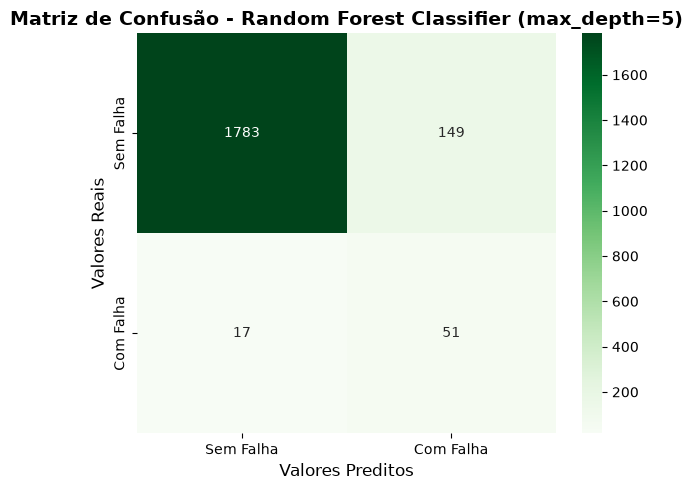

In [47]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf_final),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Sem Falha", "Com Falha"],
    yticklabels=["Sem Falha", "Com Falha"]
)

plt.title(
    "Matriz de Confusão - Random Forest Classifier (max_depth=5)",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Valores Preditos", fontsize=12)
plt.ylabel("Valores Reais", fontsize=12)

plt.tight_layout()
plt.savefig("imagens/13_matriz_confusao_rf.png", dpi=300, bbox_inches="tight")
plt.show()